In [ ]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import os
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam

# 设置数据路径
DATA_DIR = "/content/drive/MyDrive"
ERA5_MAY_2024 = os.path.join(DATA_DIR, "2024_05.nc")
ERA5_APRIL_2025 = os.path.join(DATA_DIR, "2025_04.nc")
# ERA5_MAY_2025 = os.path.join(DATA_DIR, "2025_05.nc")
ERA5_MAY_2025 = os.path.join(DATA_DIR, "2025_05_1-9.nc")


# 1. 加载并预处理数据 (保持不变)
def load_data():
    """加载并合并三个NetCDF数据集"""
    print("加载数据集...")
    ds_may_2024 = xr.open_dataset(ERA5_MAY_2024, decode_cf=True)
    ds_april_2025 = xr.open_dataset(ERA5_APRIL_2025, decode_cf=True)
    ds_may_2025 = xr.open_dataset(ERA5_MAY_2025, decode_cf=True)

    possible_time_coords = ['time', 'valid_time']
    datasets = [(ds_may_2024, "2024_05"), (ds_april_2025, "2025_04"), (ds_may_2025, "2025_05")]
    for ds, name in datasets:
        print(f"\n检查数据集 {name}:")
        time_coord = None
        for coord in possible_time_coords:
            if coord in ds.coords:
                time_coord = coord
                break
        if time_coord is None:
            raise ValueError(f"数据集 {name} 缺少时序坐标")
        if not np.issubdtype(ds[time_coord].dtype, np.datetime64):
            ds[time_coord] = pd.to_datetime(ds[time_coord].values)
        if 'number' in ds.dims:
            ds = ds.sel(number=0, drop=True)
        if 'expver' in ds.dims:
            ds = ds.sel(expver=1, drop=True)
        if time_coord != 'time':
            ds = ds.rename({time_coord: 'time'})
            ds = ds.set_coords('time')
        if name == "2024_05":
            ds_may_2024 = ds
        elif name == "2025_04":
            ds_april_2025 = ds
        else:
            ds_may_2025 = ds

    train_ds = xr.concat([ds_may_2024, ds_april_2025], dim="time")
    for ds, name in [(train_ds, "train_ds"), (ds_may_2025, "ds_may_2025")]:
        ds['t2m_celsius'] = ds['t2m'] - 273.15
        ds['d2m_celsius'] = ds['d2m'] - 273.15
        ds['tp_mm'] = ds['tp'] * 1000
        ds['hour'] = ds['time'].dt.hour
        ds['day_of_year'] = ds['time'].dt.dayofyear
        ds['hour_sin'] = np.sin(2 * np.pi * ds['hour'] / 24)
        ds['hour_cos'] = np.cos(2 * np.pi * ds['hour'] / 24)
        ds['day_of_year_sin'] = np.sin(2 * np.pi * ds['day_of_year'] / 365)
        ds['day_of_year_cos'] = np.cos(2 * np.pi * ds['day_of_year'] / 365)

    print("数据集加载完成")
    return train_ds, ds_may_2025

# 2. 特征工程
def prepare_features(ds, is_train=True):
    """构建特征矩阵"""
    print("构建特征矩阵...")
    df = ds[['t2m_celsius', 'd2m_celsius', 'ssr', 'sshf', 'sp', 'tp_mm',
             'hour', 'day_of_year', 'hour_sin', 'hour_cos',
             'day_of_year_sin', 'day_of_year_cos']].to_dataframe().reset_index()
    if is_train:
        df['t2m_lag1'] = df.groupby(['latitude', 'longitude'])['t2m_celsius'].shift(1)
        df['tp_lag1'] = df.groupby(['latitude', 'longitude'])['tp_mm'].shift(1)
    df = df.dropna()
    print(f"特征矩阵样本数: {len(df)}")
    return df

# 3. 为LSTM准备序列数据
def prepare_lstm_data(df, features, time_steps=24):
    """为LSTM创建序列数据"""
    X, y = [], []
    for lat in df['latitude'].unique():
        for lon in df['longitude'].unique():
            df_loc = df[(df['latitude'] == lat) & (df['longitude'] == lon)].sort_values('time')
            if len(df_loc) >= time_steps:
                for i in range(len(df_loc) - time_steps):
                    X.append(df_loc[features].iloc[i:i+time_steps].values)
                    y.append(df_loc['t2m_celsius'].iloc[i+time_steps])
    return np.array(X), np.array(y)

# 4. 训练模型
def train_models(df):
    """训练随机森林和LSTM模型"""
    print("训练模型...")
    features = ['latitude', 'longitude', 'd2m_celsius', 'ssr', 'sshf', 'sp', 'tp_mm',
                'hour_sin', 'hour_cos', 'day_of_year_sin', 'day_of_year_cos',
                't2m_lag1', 'tp_lag1']
    X = df[features]
    y = df['t2m_celsius']

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # 随机森林
    print("训练随机森林模型...")
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
    rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_model.fit(X_train, y_train)
    y_pred_rf = rf_model.predict(X_test)
    print("\n随机森林评估:")
    print(f"R²: {r2_score(y_test, y_pred_rf):.2f}")
    print(f"MAE: {mean_absolute_error(y_test, y_pred_rf):.2f} °C")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.2f} °C")

    # LSTM
    print("训练LSTM模型...")
    time_steps = 24
    X_lstm, y_lstm = prepare_lstm_data(df, features, time_steps)
    if len(X_lstm) == 0:
        raise ValueError("LSTM数据不足，无法训练")
    X_lstm_scaled = np.zeros_like(X_lstm)
    for i in range(X_lstm.shape[1]):
        X_lstm_scaled[:, i, :] = scaler.fit_transform(X_lstm[:, i, :])
    X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split(X_lstm_scaled, y_lstm, test_size=0.2, random_state=42)

    lstm_model = Sequential([
        LSTM(50, activation='relu', input_shape=(time_steps, len(features)), return_sequences=False),
        Dense(1)
    ])
    lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    lstm_model.fit(X_train_lstm, y_train_lstm, epochs=10, batch_size=32, verbose=1, validation_split=0.2)

    y_pred_lstm = lstm_model.predict(X_test_lstm)
    print("\nLSTM评估:")
    print(f"R²: {r2_score(y_test_lstm, y_pred_lstm):.2f}")
    print(f"MAE: {mean_absolute_error(y_test_lstm, y_pred_lstm):.2f} °C")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_test_lstm, y_pred_lstm)):.2f} °C")

    return rf_model, lstm_model, scaler, features, time_steps

# 5. 预测温度
def predict_temperature(rf_model, lstm_model, scaler, features_list, time_steps, ds_may_2025, target_date='2025-05-13'):
    """预测目标日期的温度，使用RF和LSTM的平均值"""
    print(f"预测 {target_date} 的温度...")
    target_time = pd.to_datetime(target_date)
    ds_subset = ds_may_2025
    if 'number' in ds_subset.dims:
        ds_subset = ds_subset.sel(number=0, drop=True)
    if 'expver' in ds_subset.dims:
        ds_subset = ds_subset.sel(expver=1, drop=True)

    # 选择目标日期的数据
    similar_day = ds_subset.sel(time=(ds_subset['time'].dt.month == target_time.month) &
                               (ds_subset['time'].dt.day == target_time.day))
    if len(similar_day['time']) == 0:
        print("未找到精确匹配日期，使用整个5月数据...")
        similar_day = ds_subset

    # 生成预测特征
    pred_df = prepare_features(similar_day, is_train=False)
    print(f"预测数据行数: {len(pred_df)}")
    pred_df['t2m_lag1'] = pred_df.groupby(['latitude', 'longitude'])['t2m_celsius'].shift(1).fillna(pred_df['t2m_celsius'].mean())
    pred_df['tp_lag1'] = pred_df.groupby(['latitude', 'longitude'])['tp_mm'].shift(1).fillna(pred_df['tp_mm'].mean())

    # 随机森林预测
    X_pred_rf = scaler.transform(pred_df[features_list])
    pred_df['pred_temp_rf'] = rf_model.predict(X_pred_rf)
    print(f"随机森林预测完成，预测数: {len(pred_df['pred_temp_rf'])}")

    # LSTM预测
    pred_df['pred_temp_lstm'] = np.nan  # 初始化
    X_lstm, _ = prepare_lstm_data(pred_df, features_list, time_steps)
    print(f"LSTM输入序列数: {len(X_lstm)}")

    if len(X_lstm) > 0:
        X_lstm_scaled = np.zeros_like(X_lstm)
        for i in range(X_lstm.shape[1]):
            X_lstm_scaled[:, i, :] = scaler.transform(X_lstm[:, i, :])
        pred_lstm = lstm_model.predict(X_lstm_scaled)
        print(f"LSTM预测数: {len(pred_lstm)}")

        # 为每个位置分配预测
        idx_offset = 0
        for lat in pred_df['latitude'].unique():
            for lon in pred_df['longitude'].unique():
                df_loc = pred_df[(pred_df['latitude'] == lat) & (pred_df['longitude'] == lon)].sort_values('time')
                if len(df_loc) >= time_steps:
                    num_sequences = len(df_loc) - time_steps + 1
                    if num_sequences > 0:
                        indices = df_loc.index[time_steps-1:time_steps-1+num_sequences]
                        if idx_offset + num_sequences <= len(pred_lstm):
                            pred_df.loc[indices, 'pred_temp_lstm'] = pred_lstm[idx_offset:idx_offset+num_sequences].flatten()
                            idx_offset += num_sequences
                        else:
                            print(f"警告: LSTM预测数不足，位置 ({lat}, {lon}) 跳过")

    # 填充缺失的LSTM预测
    pred_df['pred_temp_lstm'].fillna(pred_df['pred_temp_rf'], inplace=True)
    print(f"LSTM预测填充后非空数: {pred_df['pred_temp_lstm'].notna().sum()}")

    # 平均预测
    pred_df['pred_temp'] = (pred_df['pred_temp_rf'] + pred_df['pred_temp_lstm']) / 2
    return pred_df

# 6. 可视化与输出
def visualize_and_save(pred_df, target_date='2025-05-13'):
    """生成并保存可视化与预测结果"""
    target_lat, target_lon = 28.0000, 120.7000
    wenzhou_data = pred_df[
        (np.isclose(pred_df['latitude'], target_lat, atol=0.01)) &
        (np.isclose(pred_df['longitude'], target_lon, atol=0.01))
    ].copy()

    wenzhou_data['hour_cst'] = (wenzhou_data['hour'] + 8) % 24
    wenzhou_data = wenzhou_data.sort_values('hour_cst')

    # 计算统计信息
    avg_temp = wenzhou_data['pred_temp'].mean()
    min_temp = wenzhou_data['pred_temp'].min()
    max_temp = wenzhou_data['pred_temp'].max()

    print(f"\n温州肯恩大学 (28.0000°N, 120.7000°E) {target_date} 预测结果:")
    print(f"平均温度: {avg_temp:.1f}°C")
    print(f"最低温度: {min_temp:.1f}°C")
    print(f"最高温度: {max_temp:.1f}°C")
    print("\n每小时温度 (CST):")
    for _, row in wenzhou_data.iterrows():
        print(f"{int(row['hour_cst'])}:00: {row['pred_temp']:.1f}°C "
              f"(RF: {row['pred_temp_rf']:.1f}°C, LSTM: {row['pred_temp_lstm']:.1f}°C), "
              f"太阳辐射: {row['ssr']:.1f} J/m², 降水量: {row['tp_mm']:.1f} mm")

    # 可视化
    plt.figure(figsize=(12, 8))
    plt.subplot(3, 1, 1)
    plt.plot(wenzhou_data['hour_cst'], wenzhou_data['pred_temp'], 'm-', label='Average Temperature')
    plt.plot(wenzhou_data['hour_cst'], wenzhou_data['pred_temp_rf'], 'b--', label='RF Temperature')
    plt.plot(wenzhou_data['hour_cst'], wenzhou_data['pred_temp_lstm'], 'r--', label='LSTM Temperature')
    plt.title(f"Temperature Forecast - Wenzhou\n{target_date} (CST)")
    plt.xlabel("Hour (CST)")
    plt.ylabel("Temperature (°C)")
    plt.xticks(range(0, 24))
    plt.grid(True)
    plt.legend()

    plt.subplot(3, 1, 2)
    plt.plot(wenzhou_data['hour_cst'], wenzhou_data['ssr'] / 100, 'g--', label='Solar Radiation')
    plt.title(f"Solar Radiation Forecast - Wenzhou\n{target_date} (CST)")
    plt.xlabel("Hour (CST)")
    plt.ylabel("Solar Radiation (x100 J/m²)")
    plt.xticks(range(0, 24))
    plt.grid(True)
    plt.legend()

    plt.subplot(3, 1, 3)
    plt.bar(wenzhou_data['hour_cst'], wenzhou_data['tp_mm'], color='red', alpha=0.5, label='Precipitation')
    plt.title(f"Precipitation Forecast - Wenzhou\n{target_date} (CST)")
    plt.xlabel("Hour (CST)")
    plt.ylabel("Precipitation (mm)")
    plt.xticks(range(0, 24))
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    output_path = os.path.join(DATA_DIR, f"wenzhou_weather_{target_date.replace('-', '')}.png")
    plt.savefig(output_path, dpi=300)
    print(f"\n可视化结果已保存至: {output_path}")

    csv_path = os.path.join(DATA_DIR, f"wenzhou_pred_{target_date.replace('-', '')}.csv")
    wenzhou_data.to_csv(csv_path, index=False)
    print(f"预测数据已保存至: {csv_path}")

# 主程序
if __name__ == "__main__":
    train_ds, ds_may_2025 = load_data()
    train_df = prepare_features(train_ds, is_train=True)
    rf_model, lstm_model, scaler, features_list, time_steps = train_models(train_df)
    pred_df = predict_temperature(rf_model, lstm_model, scaler, features_list, time_steps, ds_may_2025, target_date='2025-05-13')
    visualize_and_save(pred_df, target_date='2025-05-13')

加载数据集...

检查数据集 2024_05:

检查数据集 2025_04:

检查数据集 2025_05:
数据集加载完成
构建特征矩阵...
特征矩阵样本数: 172634
训练模型...
训练随机森林模型...


KeyboardInterrupt: 

Daily+hour model

日模型数据时间范围: 1979-01-01 00:00:00 至 2018-12-31 00:00:00
预测目标日期: 2025-05-14 00:00:00
avg 模型 5月每日预测 MAE: 3.2534 °C
可视化已保存至: /content/drive/MyDrive/wenzhou_predict/wenzhou_avg_forecast_20250514.png
max 模型 5月每日预测 MAE: 3.4137 °C
可视化已保存至: /content/drive/MyDrive/wenzhou_predict/wenzhou_max_forecast_20250514.png
min 模型 5月每日预测 MAE: 3.3087 °C
可视化已保存至: /content/drive/MyDrive/wenzhou_predict/wenzhou_min_forecast_20250514.png

2025年05月14日日模型预测结果:
日期: 2025-05-14
平均气温: 25.2°C
最高气温: 29.9°C
最低气温: 23.0°C

模型评估 (MAE):
avg 预测 MAE: 3.2534 °C
max 预测 MAE: 3.4137 °C
min 预测 MAE: 3.3087 °C

2025年5月每日平均气温趋势:
2025-05-01: 24.5°C
2025-05-02: 22.5°C
2025-05-03: 22.7°C
2025-05-04: 19.3°C
2025-05-05: 24.1°C
2025-05-06: 23.1°C
2025-05-07: 23.2°C
2025-05-08: 21.9°C
2025-05-09: 24.3°C
2025-05-10: 22.5°C
2025-05-11: 19.8°C
2025-05-12: 22.7°C
2025-05-13: 21.7°C
2025-05-14: 22.2°C
2025-05-15: 22.1°C
2025-05-16: 21.6°C
2025-05-17: 20.2°C
2025-05-18: 19.5°C
2025-05-19: 20.9°C
2025-05-20: 20.1°C
2025-05-21: 22.8°C
2025-05-22: 21.

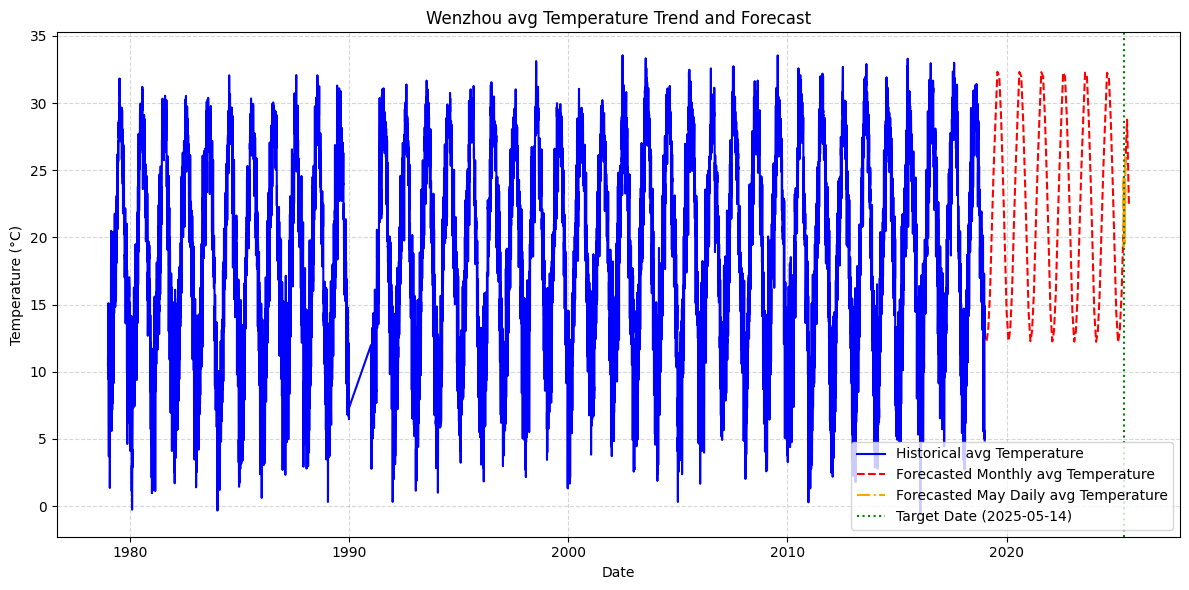

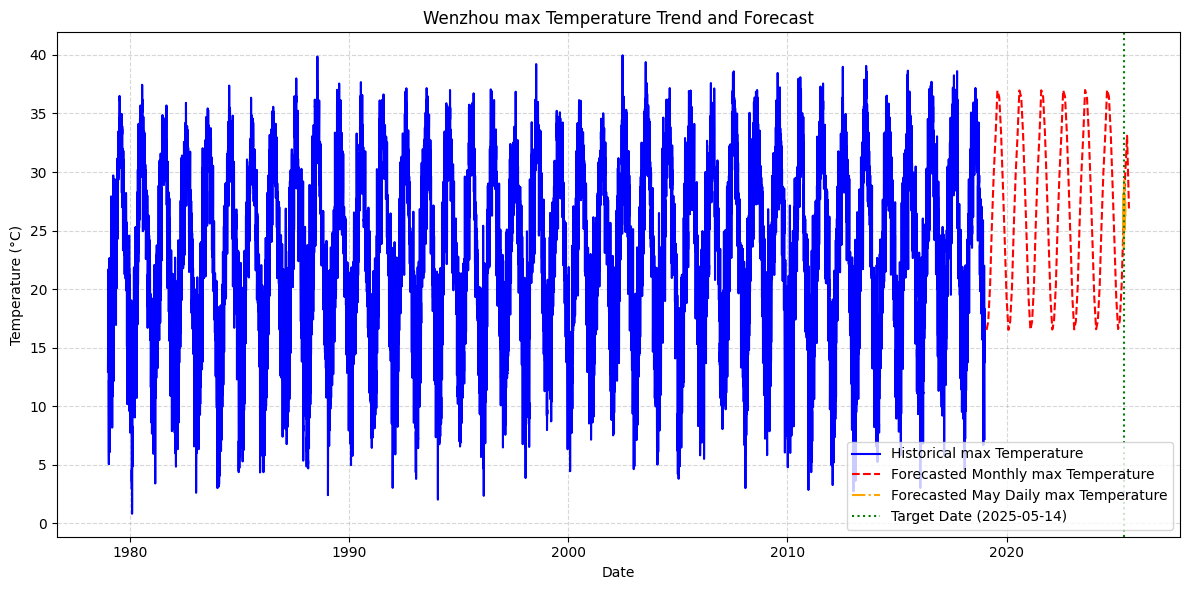

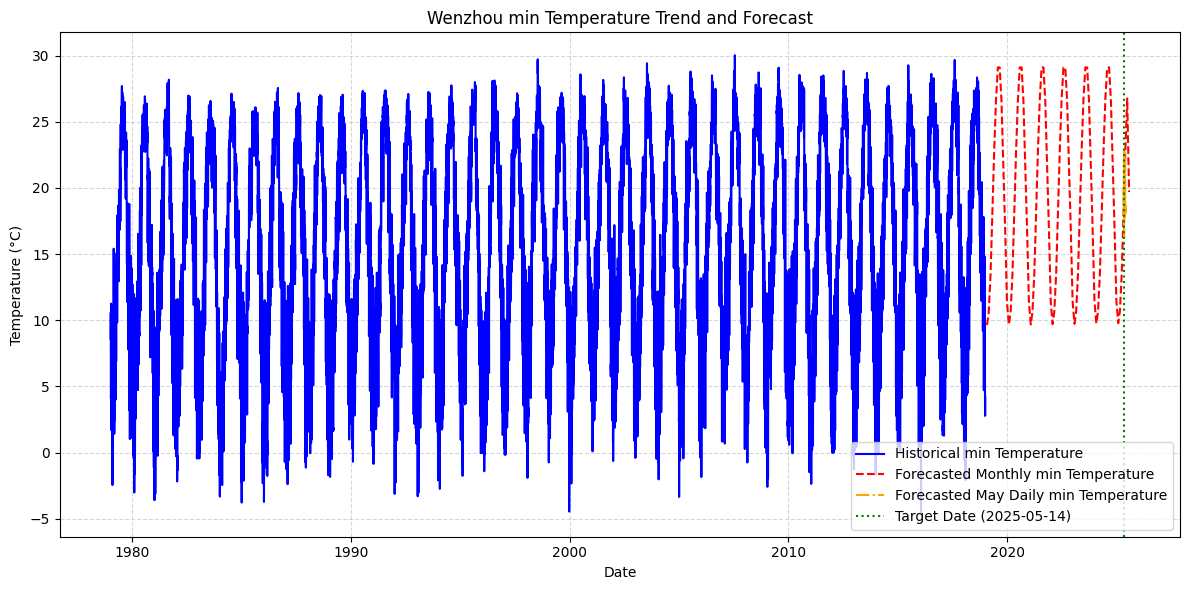

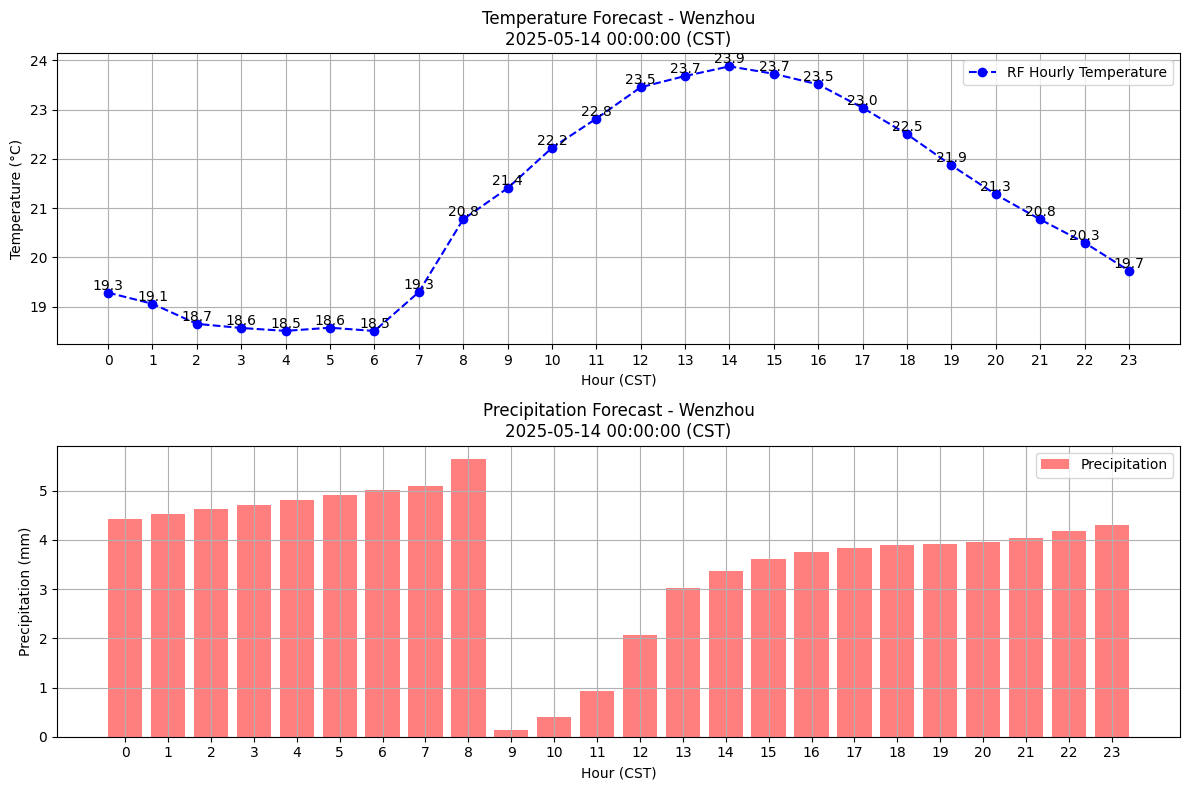

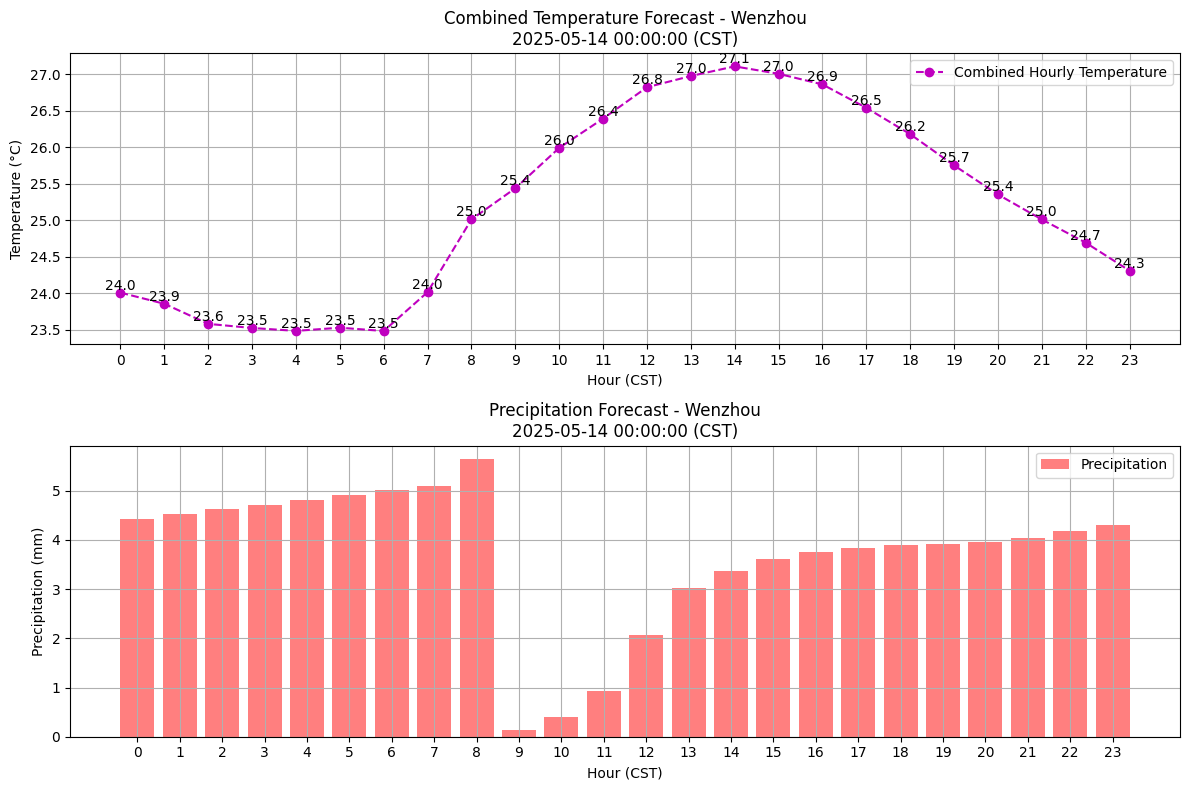

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import glob
import warnings
import xarray as xr
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import plot_tree
import os

# 抑制警告
warnings.filterwarnings("ignore")

# 数据路径
DATA_DIR = "/content/drive/MyDrive"
OUTPUT_DIR = os.path.join(DATA_DIR, "wenzhou_predict")
ERA5_MAY_2024 = os.path.join(DATA_DIR, "2024_05.nc")
ERA5_APRIL_2025 = os.path.join(DATA_DIR, "2025_04.nc")
ERA5_MAY_2025 = os.path.join(DATA_DIR, "2025_05_1-9.nc")

# 创建输出文件夹
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

# --- 日模型 ---
def load_and_preprocess_daily_data():
    all_files = glob.glob("/content/drive/MyDrive/1979-2018/wenzhou_temperature_*.csv")
    df = pd.concat([pd.read_csv(f) for f in all_files])
    df["date"] = pd.to_datetime(df["date"])
    df.sort_values("date", inplace=True)
    df.set_index("date", inplace=True)
    df = df.rename(columns={'temp_avg': 'avg', 'temp_min': 'min', 'temp_max': 'max'})
    for col in ['avg', 'max', 'min']:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        df[col] = df[col].clip(lower=Q1 - 1.5*IQR, upper=Q3 + 1.5*IQR)  # 去除异常值
    df = df.interpolate(method='time')  # 插值缺失值
    return df

def forecast_daily_temperature(data, column, target_date):
    # 按月重采样，计算月均值
    data_monthly = data[column].resample('M').mean()

    # 季节分解：T(t) = Trend(t) + Seasonal(t) + Residual(t)，分离长期趋势和季节性
    decomposition = seasonal_decompose(data_monthly, model='additive', period=12)
    trend = decomposition.trend  # 长期趋势，反映温度的年际变化
    seasonal = decomposition.seasonal  # 季节性分量，周期为12个月
    trend = trend.interpolate().fillna(method='bfill').fillna(method='ffill')  # 插值趋势缺失值
    detrended = data_monthly - trend  # 去趋势，保留季节性和残差，便于后续建模
    detrended = detrended.fillna(method='ffill').fillna(method='bfill')  # 插值残差

    # Holt-Winters 指数平滑：F(t+m) = L_t + m*b_t + S_{t+m-s}，建模残差的季节性
    # 其中 L_t = α(y_t - S_{t-s}) + (1-α)(L_{t-1} + b_{t-1})，b_t = β(L_t - L_{t-1}) + (1-β)b_{t-1}
    # S_t = γ(y_t - L_t) + (1-γ)S_{t-s}，预测未来值
    fit = ExponentialSmoothing(detrended, seasonal_periods=12, trend='add', seasonal='add').fit()
    last_date = data_monthly.index.max()
    forecast_steps = (pd.to_datetime('2025-05-31') - last_date).days // 30 + 1  # 计算预测步长
    forecast = fit.forecast(forecast_steps)  # 预测残差

    # 趋势外推：trend_forecast[i] = last_trend + i * trend_diff * 0.5，减缓趋势变化
    trend_diff = trend.diff().mean() * 0.5  # 平均趋势变化率，乘以0.5减缓外推速度
    last_trend = trend.iloc[-1]
    trend_forecast = [last_trend + i * trend_diff for i in range(forecast_steps)]

    # 提取5月季节性分量
    may_seasonal = seasonal[pd.to_datetime('2025-05-01').month - 1]  # 5月季节性值
    final_forecast = forecast + trend_forecast + may_seasonal  # 合并预测：forecast + trend + seasonal

    # 调整预测：final_forecast[-1] = 0.9 * historical_may_mean + 0.1 * final_forecast[-1]
    # 使用历史5月均值（90%权重）微调，保持与历史一致
    historical_min = data_monthly.min()
    historical_max = data_monthly.max()
    historical_may_mean = data_monthly[data_monthly.index.month == 5].mean()
    final_forecast[-1] = 0.9 * historical_may_mean + 0.1 * final_forecast[-1]
    final_forecast = np.clip(final_forecast, historical_min - 2, historical_max + 2)  # 限制范围

    # 生成月度预测和5月每日预测
    forecast_dates = pd.date_range(start=last_date + pd.offsets.MonthEnd(), periods=forecast_steps, freq='M')
    forecast_df = pd.DataFrame({column + '_pred': final_forecast}, index=forecast_dates)
    may_days = pd.date_range(start='2025-05-01', end='2025-05-31', freq='D')
    may_base = final_forecast[-1]
    may_fluctuation = np.random.normal(0, 1.5, len(may_days))  # 添加正态随机波动，σ=1.5°C
    may_forecast = may_base + may_fluctuation
    may_forecast = np.clip(may_forecast, historical_min, historical_max)
    may_df = pd.DataFrame({column + '_pred': may_forecast}, index=may_days)

    # 评估：MAE = (1/n) * Σ|y_i - ŷ_i|，比较预测与历史数据
    historical_may = data[data.index.month == 5][column].resample('D').mean().iloc[-31:]  # 取最近5月每日均值
    mae = mean_absolute_error(historical_may, may_forecast) if len(historical_may) == len(may_forecast) else np.nan
    print(f"{column} 模型 5月每日预测 MAE: {mae:.4f} °C")

    target_month = pd.to_datetime('2025-05-31')
    target_pred = forecast_df.loc[target_month]
    return target_pred.values[0], forecast_df, may_df, mae

def plot_daily_forecast(data, forecast_df, may_df, column, target_date, last_data_date):
    plt.figure(figsize=(12, 6))
    plt.plot(data.index, data[column], label='Historical ' + column + ' Temperature', color='blue')
    plt.plot(forecast_df.index, forecast_df[column + '_pred'], label='Forecasted Monthly ' + column + ' Temperature', color='red', linestyle='--')
    plt.plot(may_df.index, may_df[column + '_pred'], label='Forecasted May Daily ' + column + ' Temperature', color='orange', linestyle='-.')
    plt.axvline(target_date, color='green', linestyle=':', label=f'Target Date ({target_date.strftime("%Y-%m-%d")})')
    plt.title(f'Wenzhou {column} Temperature Trend and Forecast')
    plt.xlabel('Date')
    plt.ylabel('Temperature (°C)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    output_path = os.path.join(OUTPUT_DIR, f'wenzhou_{column}_forecast_{target_date.strftime("%Y%m%d")}.png')
    plt.savefig(output_path, dpi=300)
    print(f"可视化已保存至: {output_path}")

def plot_may_daily_trends(may_dfs, target_date):
    plt.figure(figsize=(15, 8))
    plt.plot(may_dfs['avg'].index, may_dfs['avg']['avg_pred'], label='Average Temperature', color='blue', marker='o', markersize=4)
    plt.plot(may_dfs['max'].index, may_dfs['max']['max_pred'], label='Maximum Temperature', color='red', marker='^', markersize=4)
    plt.plot(may_dfs['min'].index, may_dfs['min']['min_pred'], label='Minimum Temperature', color='green', marker='v', markersize=4)
    plt.axvline(target_date, color='purple', linestyle=':', label=f'Target Date ({target_date.strftime("%Y-%m-%d")})')
    plt.title('Wenzhou Daily Temperature Trends for May 2025')
    plt.xlabel('Date')
    plt.ylabel('Temperature (°C)')
    plt.xticks(pd.date_range(start='2025-05-01', end='2025-06-01', freq='5D'), rotation=45)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    output_path = os.path.join(OUTPUT_DIR, f'wenzhou_may_daily_trends_{target_date.strftime("%Y%m%d")}.png')
    plt.savefig(output_path, dpi=300)
    print(f"5月每日温度趋势图已保存至: {output_path}")
    plt.close()

def daily_forecast_main(target_date):
    df = load_and_preprocess_daily_data()
    last_data_date = df.index.max()
    print(f"日模型数据时间范围: {df.index.min()} 至 {last_data_date}")
    print(f"预测目标日期: {target_date}")
    predictions = {}
    forecast_dfs = {}
    may_dfs = {}
    mae_scores = {}  # 存储 MAE 评估结果
    for col in ['avg', 'max', 'min']:
        pred_value, forecast_df, may_df, mae = forecast_daily_temperature(df, col, target_date)
        predictions[col] = pred_value
        forecast_dfs[col] = forecast_df
        may_dfs[col] = may_df
        mae_scores[col] = mae
        plot_daily_forecast(df, forecast_df, may_df, col, target_date, last_data_date)
    print(f"\n{target_date.strftime('%Y年%m月%d日')}日模型预测结果:")
    print(f"日期: {target_date.strftime('%Y-%m-%d')}")
    print(f"平均气温: {predictions['avg']:.1f}°C")
    print(f"最高气温: {predictions['max']:.1f}°C")
    print(f"最低气温: {predictions['min']:.1f}°C")
    print("\n模型评估 (MAE):")
    for col, mae in mae_scores.items():
        print(f"{col} 预测 MAE: {mae:.4f} °C")
    print(f"\n2025年5月每日平均气温趋势:")
    may_values = may_dfs['avg']['avg_pred']
    for date, temp in zip(may_values.index, may_values):
        print(f"{date.strftime('%Y-%m-%d')}: {temp:.1f}°C")
    plot_may_daily_trends(may_dfs, target_date)
    return predictions, may_dfs, mae_scores

# --- 小时模型 ---
def load_hourly_data():
    print("加载小时数据集...")
    ds_may_2024 = xr.open_dataset(ERA5_MAY_2024, decode_cf=True)
    ds_april_2025 = xr.open_dataset(ERA5_APRIL_2025, decode_cf=True)
    ds_may_2025 = xr.open_dataset(ERA5_MAY_2025, decode_cf=True)
    possible_time_coords = ['time', 'valid_time']
    datasets = [(ds_may_2024, "2024_05"), (ds_april_2025, "2025_04"), (ds_may_2025, "2025_05")]
    for ds, name in datasets:
        print(f"\n检查数据集 {name}:")
        time_coord = None
        for coord in possible_time_coords:
            if coord in ds.coords:
                time_coord = coord
                break
        if time_coord is None:
            raise ValueError(f"数据集 {name} 缺少时序坐标")
        if not np.issubdtype(ds[time_coord].dtype, np.datetime64):
            ds[time_coord] = pd.to_datetime(ds[time_coord].values)
        if 'number' in ds.dims:
            ds = ds.sel(number=0, drop=True)
        if 'expver' in ds.dims:
            ds = ds.sel(expver=1, drop=True)
        if time_coord != 'time':
            ds = ds.rename({time_coord: 'time'})
            ds = ds.set_coords('time')
        if name == "2024_05":
            ds_may_2024 = ds
        elif name == "2025_04":
            ds_april_2025 = ds
        else:
            ds_may_2025 = ds
    train_ds = xr.concat([ds_may_2024, ds_april_2025], dim="time")
    for ds, name in [(train_ds, "train_ds"), (ds_may_2025, "ds_may_2025")]:
        ds['t2m_celsius'] = ds['t2m'] - 273.15  # 转换 Kelvin 到 Celsius
        ds['d2m_celsius'] = ds['d2m'] - 273.15
        ds['tp_mm'] = ds['tp'] * 1000  # 降水量转换至 mm
        ds['hour'] = ds['time'].dt.hour
        ds['day_of_year'] = ds['time'].dt.dayofyear
        ds['hour_sin'] = np.sin(2 * np.pi * ds['hour'] / 24)  # 周期性特征
        ds['hour_cos'] = np.cos(2 * np.pi * ds['hour'] / 24)
        ds['day_of_year_sin'] = np.sin(2 * np.pi * ds['day_of_year'] / 365)
        ds['day_of_year_cos'] = np.cos(2 * np.pi * ds['day_of_year'] / 365)
    print("小时数据集加载完成")
    return train_ds, ds_may_2025

def prepare_hourly_features(ds, is_train=True, target_lat=28.0000, target_lon=120.7000):
    print("构建小时特征矩阵...")
    df = ds.sel(latitude=target_lat, longitude=target_lon, method='nearest')[
        ['t2m_celsius', 'd2m_celsius', 'ssr', 'sshf', 'sp', 'tp_mm',
         'hour', 'day_of_year', 'hour_sin', 'hour_cos',
         'day_of_year_sin', 'day_of_year_cos']
    ].to_dataframe().reset_index()
    if is_train:
        df['t2m_lag1'] = df.groupby(['latitude', 'longitude'])['t2m_celsius'].shift(1)  # 滞后特征
        df['tp_lag1'] = df.groupby(['latitude', 'longitude'])['tp_mm'].shift(1)
    df = df.dropna()
    print(f"特征矩阵样本数: {len(df)}")
    return df

def train_hourly_model(df):
    print("训练随机森林模型...")
    features = ['latitude', 'longitude', 'd2m_celsius', 'ssr', 'sshf', 'sp', 'tp_mm',
                'hour_sin', 'hour_cos', 'day_of_year_sin', 'day_of_year_cos',
                't2m_lag1', 'tp_lag1']
    X = df[features]
    y = df['t2m_celsius']

    # 标准化特征：x_scaled = (x - μ) / σ，消除量纲影响
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # 数据分割：80%训练，20%测试
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
    print(f"训练集样本数: {len(X_train)}, 测试集样本数: {len(X_test)}")

    # 初始化随机森林：ŷ = (1/N) Σ T_i(x)，N=100棵树
    rf_model = RandomForestRegressor(n_estimators=100, random_state=42, min_samples_split=2, min_samples_leaf=1)
    print("随机森林参数:")
    print(f"  - 树的数量: {rf_model.n_estimators}")
    print(f"  - 最小分裂样本数: {rf_model.min_samples_split}")
    print(f"  - 最小叶节点样本数: {rf_model.min_samples_leaf}")
    print(f"  - 随机种子: {rf_model.random_state}")

    # 训练模型：最小化 MSE = (1/n) Σ (y_i - ŷ_i)^2
    print("开始训练随机森林模型...")
    rf_model.fit(X_train, y_train)
    print("训练完成")

    # 预测测试集
    y_pred_rf = rf_model.predict(X_test)

    # 评估指标：R² = 1 - Σ(y_i - ŷ_i)^2 / Σ(y_i - ȳ)^2，MAE，RMSE
    r2 = r2_score(y_test, y_pred_rf)
    mae = mean_absolute_error(y_test, y_pred_rf)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
    print("\n随机森林评估指标:")
    print(f"  - R² 分数: {r2:.4f}")
    print(f"  - 平均绝对误差 (MAE): {mae:.4f} °C")
    print(f"  - 均方根误差 (RMSE): {rmse:.4f} °C")

    # 特征重要性：基于MSE减少量
    feature_importance = pd.DataFrame({
        'feature': features,
        'importance': rf_model.feature_importances_
    }).sort_values('importance', ascending=False)
    print("\n特征重要性排名:")
    for idx, row in feature_importance.iterrows():
        print(f"  - {row['feature']}: {row['importance']:.4f}")

    # 可视化前3棵决策树
    print("\n生成决策树可视化...")
    for tree_idx in range(3):
        single_tree = rf_model.estimators_[tree_idx]
        plt.figure(figsize=(30, 15))
        plot_tree(single_tree,
                  feature_names=features,
                  filled=True,
                  rounded=True,
                  max_depth=4,
                  fontsize=10,
                  impurity=True,
                  node_ids=True,
                  proportion=False,
                  precision=3)
        plt.title(f"Decision Tree {tree_idx} from Random Forest (Top 5 Layers)")
        tree_output_path = os.path.join(OUTPUT_DIR, f"decision_tree_example_{tree_idx}.png")
        plt.savefig(tree_output_path, dpi=300, bbox_inches='tight')
        plt.close()
        print(f"决策树 {tree_idx} 可视化已保存至: {tree_output_path}")

    return rf_model, scaler, features

def predict_hourly_temperature(rf_model, scaler, features_list, ds_may_2025, target_date='2025-05-14'):
    print(f"预测 {target_date} 的小时气温...")
    target_time = pd.to_datetime(target_date)
    ds_subset = ds_may_2025
    if 'number' in ds_subset.dims:
        ds_subset = ds_subset.sel(number=0, drop=True)
    if 'expver' in ds_subset.dims:
        ds_subset = ds_subset.sel(expver=1, drop=True)
    similar_day = ds_subset.sel(time=(ds_subset['time'].dt.month == target_time.month) &
                               (ds_subset['time'].dt.day == target_time.day))
    if len(similar_day['time']) == 0:
        print("未找到精确匹配日期，使用整个5月数据...")
        similar_day = ds_may_2025.sel(time=slice('2025-05-01', '2025-05-31'))
    pred_df = prepare_hourly_features(similar_day, is_train=False)
    print(f"预测数据行数: {len(pred_df)}")
    pred_df['t2m_lag1'] = pred_df.groupby(['latitude', 'longitude'])['t2m_celsius'].shift(1).fillna(pred_df['t2m_celsius'].mean())
    pred_df['tp_lag1'] = pred_df.groupby(['latitude', 'longitude'])['tp_mm'].shift(1).fillna(pred_df['tp_mm'].mean())
    X_pred_rf = scaler.transform(pred_df[features_list])
    pred_df['pred_temp'] = rf_model.predict(X_pred_rf)
    print(f"随机森林预测完成，预测数: {len(pred_df['pred_temp'])}")
    return pred_df

def visualize_hourly_forecast(pred_df, target_date='2025-05-14'):
    target_lat, target_lon = 28.0000, 120.7000
    wenzhou_data = pred_df[
        (np.isclose(pred_df['latitude'], target_lat, atol=0.01)) &
        (np.isclose(pred_df['longitude'], target_lon, atol=0.01))
    ].copy()
    wenzhou_data['hour_cst'] = (wenzhou_data['hour'] + 8) % 24
    wenzhou_data = wenzhou_data.sort_values('hour_cst')
    hourly_avg = wenzhou_data.groupby('hour_cst')['pred_temp'].mean().reindex(range(24), fill_value=np.nan)
    avg_temp = hourly_avg.mean()
    min_temp = hourly_avg.min()
    max_temp = hourly_avg.max()
    print(f"\n温州肯恩大学 (28.0000°N, 120.7000°E) {target_date} 逐小时预测结果（随机森林）:")
    print(f"平均气温: {avg_temp:.1f}°C")
    print(f"最低气温: {min_temp:.1f}°C")
    print(f"最高气温: {max_temp:.1f}°C")
    print("\n每小时平均气温 (CST):")
    for hour, temp in hourly_avg.items():
        print(f"{int(hour)}:00: {temp:.1f}°C")
    plt.figure(figsize=(12, 4))
    plt.plot(hourly_avg.index, hourly_avg.values, 'b--', label='RF Hourly Temperature', marker='o')
    for i, temp in enumerate(hourly_avg.values):
        if not np.isnan(temp):
            plt.text(hourly_avg.index[i], temp, f'{temp:.1f}', ha='center', va='bottom')
    plt.title(f"Random Forest Temperature Forecast - Wenzhou\n{target_date} (CST)")
    plt.xlabel("Hour (CST)")
    plt.ylabel("Temperature (°C)")
    plt.xticks(range(0, 24))
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    avg_temp_path = os.path.join(OUTPUT_DIR, f"wenzhou_rf_avg_temp_{target_date.strftime('%Y%m%d')}.png")
    plt.savefig(avg_temp_path, dpi=300)
    print(f"小时模型温度曲线已保存至: {avg_temp_path}")
    plt.close()
    plt.figure(figsize=(12, 8))
    plt.subplot(2, 1, 1)
    plt.plot(hourly_avg.index, hourly_avg.values, 'b--', label='RF Hourly Temperature', marker='o')
    for i, temp in enumerate(hourly_avg.values):
        if not np.isnan(temp):
            plt.text(hourly_avg.index[i], temp, f'{temp:.1f}', ha='center', va='bottom')
    plt.title(f"Temperature Forecast - Wenzhou\n{target_date} (CST)")
    plt.xlabel("Hour (CST)")
    plt.ylabel("Temperature (°C)")
    plt.xticks(range(0, 24))
    plt.grid(True)
    plt.legend()
    plt.subplot(2, 1, 2)
    hourly_tp = wenzhou_data.groupby('hour_cst')['tp_mm'].mean().reindex(range(24), fill_value=0)
    plt.bar(hourly_tp.index, hourly_tp.values, color='red', alpha=0.5, label='Precipitation')
    plt.title(f"Precipitation Forecast - Wenzhou\n{target_date} (CST)")
    plt.xlabel("Hour (CST)")
    plt.ylabel("Precipitation (mm)")
    plt.xticks(range(0, 24))
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    output_path = os.path.join(OUTPUT_DIR, f"wenzhou_weather_rf_{target_date.strftime('%Y%m%d')}.png")
    plt.savefig(output_path, dpi=300)
    print(f"可视化结果已保存至: {output_path}")
    csv_path = os.path.join(OUTPUT_DIR, f"wenzhou_pred_rf_{target_date.strftime('%Y%m%d')}.csv")
    wenzhou_data.to_csv(csv_path, index=False)
    print(f"预测数据已保存至: {csv_path}")
    return wenzhou_data, avg_temp

# --- 结合模型 ---
def combine_predictions(daily_predictions, hourly_data):
    print("结合日模型和小时模型预测...")
    hourly_avg = hourly_data['pred_temp'].mean()
    hourly_min = hourly_data['pred_temp'].min()
    hourly_max = hourly_data['pred_temp'].max()
    print(f"小时模型原始统计: 平均 {hourly_avg:.1f}°C, 最低 {hourly_min:.1f}°C, 最高 {hourly_max:.1f}°C")
    shift = daily_predictions['avg'] - hourly_avg  # 平移：shift = daily_avg - hourly_avg
    adjusted_temp = hourly_data['pred_temp'] + shift
    current_range = adjusted_temp.max() - adjusted_temp.min()
    target_range = daily_predictions['max'] - daily_predictions['min']
    if current_range > 0:
        scale = target_range / current_range  # 缩放：scale = target_range / current_range
        adjusted_temp = daily_predictions['min'] + (adjusted_temp - adjusted_temp.min()) * scale
    else:
        adjusted_temp = adjusted_temp
    final_avg = adjusted_temp.mean()
    final_shift = daily_predictions['avg'] - final_avg  # 微调平均值
    adjusted_temp = adjusted_temp + final_shift
    hourly_data['combined_temp'] = adjusted_temp
    final_avg = hourly_data['combined_temp'].mean()
    final_min = hourly_data['combined_temp'].min()
    final_max = hourly_data['combined_temp'].max()
    print(f"结合后统计: 平均 {final_avg:.1f}°C, 最低 {final_min:.1f}°C, 最高 {final_max:.1f}°C")
    return hourly_data, final_avg

def visualize_combined_forecast(hourly_data, rf_avg_temp, target_date='2025-05-14'):
    hourly_avg = hourly_data.groupby('hour_cst')['combined_temp'].mean().reindex(range(24), fill_value=np.nan)
    avg_temp = hourly_avg.mean()
    print(f"\n温州肯恩大学 (28.0000°N, 120.7000°E) {target_date} 结合模型逐小时平均温度:")
    print("\n每小时平均气温 (CST):")
    for hour, temp in hourly_avg.items():
        print(f"{int(hour)}:00: {temp:.1f}°C")
    plt.figure(figsize=(12, 4))
    plt.plot(hourly_avg.index, hourly_avg.values, 'm--', label='Combined Hourly Temperature', marker='o')
    for i, temp in enumerate(hourly_avg.values):
        if not np.isnan(temp):
            plt.text(hourly_avg.index[i], temp, f'{temp:.1f}', ha='center', va='bottom')
    plt.title(f"Combined Temperature Forecast - Wenzhou\n{target_date} (CST)")
    plt.xlabel("Hour (CST)")
    plt.ylabel("Temperature (°C)")
    plt.xticks(range(0, 24))
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    avg_temp_path = os.path.join(OUTPUT_DIR, f"wenzhou_combined_avg_temp_{target_date.strftime('%Y%m%d')}.png")
    plt.savefig(avg_temp_path, dpi=300)
    print(f"结合模型温度曲线已保存至: {avg_temp_path}")
    plt.close()
    plt.figure(figsize=(12, 8))
    plt.subplot(2, 1, 1)
    plt.plot(hourly_avg.index, hourly_avg.values, 'm--', label='Combined Hourly Temperature', marker='o')
    for i, temp in enumerate(hourly_avg.values):
        if not np.isnan(temp):
            plt.text(hourly_avg.index[i], temp, f'{temp:.1f}', ha='center', va='bottom')
    plt.title(f"Combined Temperature Forecast - Wenzhou\n{target_date} (CST)")
    plt.xlabel("Hour (CST)")
    plt.ylabel("Temperature (°C)")
    plt.xticks(range(0, 24))
    plt.grid(True)
    plt.legend()
    plt.subplot(2, 1, 2)
    hourly_tp = hourly_data.groupby('hour_cst')['tp_mm'].mean().reindex(range(24), fill_value=0)
    plt.bar(hourly_tp.index, hourly_tp.values, color='red', alpha=0.5, label='Precipitation')
    plt.title(f"Precipitation Forecast - Wenzhou\n{target_date} (CST)")
    plt.xlabel("Hour (CST)")
    plt.ylabel("Precipitation (mm)")
    plt.xticks(range(0, 24))
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    output_path = os.path.join(OUTPUT_DIR, f"wenzhou_weather_combined_{target_date.strftime('%Y%m%d')}.png")
    plt.savefig(output_path, dpi=300)
    print(f"可视化结果已保存至: {output_path}")
    csv_path = os.path.join(OUTPUT_DIR, f"wenzhou_pred_combined_{target_date.strftime('%Y%m%d')}.csv")
    hourly_data.to_csv(csv_path, index=False)
    print(f"预测数据已保存至: {csv_path}")
    rf_hourly_avg = hourly_data.groupby('hour_cst')['pred_temp'].mean().reindex(range(24), fill_value=np.nan)
    plt.figure(figsize=(12, 8))
    plt.subplot(2, 1, 1)
    plt.plot(rf_hourly_avg.index, rf_hourly_avg.values, 'b--', label='RF Hourly Temperature', marker='o')
    for i, temp in enumerate(rf_hourly_avg.values):
        if not np.isnan(temp):
            plt.text(rf_hourly_avg.index[i], temp, f'{temp:.1f}', ha='center', va='bottom')
    plt.plot(hourly_avg.index, hourly_avg.values, 'm--', label='Combined Hourly Temperature', marker='o')
    for i, temp in enumerate(hourly_avg.values):
        if not np.isnan(temp):
            plt.text(hourly_avg.index[i], temp, f'{temp:.1f}', ha='center', va='bottom')
    plt.title(f"Temperature Comparison - Wenzhou\n{target_date} (CST)")
    plt.xlabel("Hour (CST)")
    plt.ylabel("Temperature (°C)")
    plt.xticks(range(0, 24))
    plt.grid(True)
    plt.legend()
    plt.subplot(2, 1, 2)
    hourly_tp = hourly_data.groupby('hour_cst')['tp_mm'].mean().reindex(range(24), fill_value=0)
    plt.bar(hourly_tp.index, hourly_tp.values, color='red', alpha=0.5, label='Precipitation')
    plt.title(f"Precipitation Forecast - Wenzhou\n{target_date} (CST)")
    plt.xlabel("Hour (CST)")
    plt.ylabel("Precipitation (mm)")
    plt.xticks(range(0, 24))
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    comparison_path = os.path.join(OUTPUT_DIR, f"wenzhou_weather_comparison_{target_date.strftime('%Y%m%d')}.png")
    plt.savefig(comparison_path, dpi=300)
    print(f"合并温度和降水量对比图已保存至: {comparison_path}")
    plt.close()

# 主程序
if __name__ == "__main__":
    target_date = pd.to_datetime('2025-05-14')
    daily_predictions, may_dfs, mae_scores = daily_forecast_main(target_date)
    train_ds, ds_may_2025 = load_hourly_data()
    train_df = prepare_hourly_features(train_ds, is_train=True)
    rf_model, scaler, features_list = train_hourly_model(train_df)
    pred_df = predict_hourly_temperature(rf_model, scaler, features_list, ds_may_2025, target_date=target_date)
    wenzhou_data, rf_avg_temp = visualize_hourly_forecast(pred_df, target_date=target_date)
    combined_data, combined_avg_temp = combine_predictions(daily_predictions, wenzhou_data)
    visualize_combined_forecast(combined_data, rf_avg_temp, target_date=target_date)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import glob
import warnings
import xarray as xr
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import os

# 抑制警告
warnings.filterwarnings("ignore")

# 数据路径
DATA_DIR = "/content/drive/MyDrive"
OUTPUT_DIR = os.path.join(DATA_DIR, "wenzhou_predict")
ERA5_MAY_2024 = os.path.join(DATA_DIR, "2024_05.nc")
ERA5_APRIL_2025 = os.path.join(DATA_DIR, "2025_04.nc")
ERA5_MAY_2025 = os.path.join(DATA_DIR, "2025_05_1-9.nc")

# 创建输出文件夹
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

# --- 日模型 ---
def load_and_preprocess_daily_data():
    all_files = glob.glob("/content/drive/MyDrive/1979-2018/wenzhou_temperature_*.csv")
    df = pd.concat([pd.read_csv(f) for f in all_files])
    df["date"] = pd.to_datetime(df["date"])
    df.sort_values("date", inplace=True)
    df.set_index("date", inplace=True)
    df = df.rename(columns={'temp_avg': 'avg', 'temp_min': 'min', 'temp_max': 'max'})
    for col in ['avg', 'max', 'min']:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        df[col] = df[col].clip(lower=Q1 - 1.5*IQR, upper=Q3 + 1.5*IQR)
    df = df.interpolate(method='time')
    return df

def forecast_daily_temperature(data, column, target_date):
    # 提取历史5月每日数据
    may_data = data[data.index.month == 5].resample('D').mean()

    # 确保没有缺失值：用前向/后向填充或插值
    may_data = may_data.interpolate(method='time').fillna(method='ffill').fillna(method='bfill')

    # 检查缺失值
    if may_data[column].isna().any():
        raise ValueError(f"Still found NaN values in {column} after interpolation: {may_data[may_data[column].isna()]}")

    # 季节分解：T(t) = Trend(t) + Seasonal(t) + Residual(t)，周期为31天
    decomposition = seasonal_decompose(may_data[column], model='additive', period=31)
    trend = decomposition.trend
    seasonal = decomposition.seasonal
    trend = trend.interpolate().fillna(method='bfill').fillna(method='ffill')
    detrended = may_data[column] - trend
    detrended = detrended.fillna(method='ffill').fillna(method='bfill')

    # Holt-Winters 指数平滑：F(t+m) = L_t + m*b_t + S_{t+m-s}，周期为31天
    fit = ExponentialSmoothing(detrended, seasonal_periods=31, trend='add', seasonal='add').fit()
    forecast = fit.forecast(31)  # 预测5月31天

    # 趋势外推：trend_forecast[i] = last_trend + i * trend_diff * 0.5
    trend_diff = trend.diff().mean() * 0.5
    last_trend = trend.iloc[-1]
    trend_forecast = [last_trend + i * trend_diff for i in range(31)]

    # 提取5月14日季节性分量
    may_14_seasonal = seasonal[13]  # 5月14日索引为13（0-based）
    final_forecast = forecast + trend_forecast + may_14_seasonal

    # 调整预测：使用历史5月均值
    historical_may_mean = may_data[column].mean()
    final_forecast[-1] = 0.9 * historical_may_mean + 0.1 * final_forecast[-1]
    historical_min = may_data[column].min()
    historical_max = may_data[column].max()
    final_forecast = np.clip(final_forecast, historical_min - 2, historical_max + 2)

    # 生成5月每日预测
    may_days = pd.date_range(start='2025-05-01', end='2025-05-31', freq='D')
    may_base = final_forecast[-1]
    may_fluctuation = np.random.normal(0, 1.5, len(may_days))
    may_forecast = may_base + may_fluctuation
    may_forecast = np.clip(may_forecast, historical_min, historical_max)
    may_df = pd.DataFrame({column + '_pred': may_forecast}, index=may_days)

    # 评估MAE
    historical_may = data[data.index.month == 5][column].resample('D').mean().iloc[-31:]
    historical_may = historical_may.interpolate(method='time').fillna(method='ffill').fillna(method='bfill')
    mae = mean_absolute_error(historical_may, may_forecast) if len(historical_may) == len(may_forecast) else np.nan
    print(f"{column} 模型 5月每日预测 MAE: {mae:.4f} °C")

    target_pred = may_df.loc[pd.to_datetime('2025-05-14')]
    return target_pred.values[0], may_df, mae

def plot_may_daily_trends(may_dfs, target_date):
    plt.figure(figsize=(15, 8))
    plt.plot(may_dfs['avg'].index, may_dfs['avg']['avg_pred'], label='Average Temperature', color='blue', marker='o', markersize=4)
    plt.plot(may_dfs['max'].index, may_dfs['max']['max_pred'], label='Maximum Temperature', color='red', marker='^', markersize=4)
    plt.plot(may_dfs['min'].index, may_dfs['min']['min_pred'], label='Minimum Temperature', color='green', marker='v', markersize=4)
    plt.axvline(target_date, color='purple', linestyle=':', label=f'Target Date ({target_date.strftime("%Y-%m-%d")})')
    plt.title('Wenzhou Daily Temperature Trends for May 2025')
    plt.xlabel('Date')
    plt.ylabel('Temperature (°C)')
    plt.xticks(pd.date_range(start='2025-05-01', end='2025-06-01', freq='5D'), rotation=45)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    output_path = os.path.join(OUTPUT_DIR, f'wenzhou_may_daily_trends_{target_date.strftime("%Y%m%d")}.png')
    plt.savefig(output_path, dpi=300)
    print(f"5月每日温度趋势图已保存至: {output_path}")
    plt.close()

def daily_forecast_main(target_date):
    df = load_and_preprocess_daily_data()
    last_data_date = df.index.max()
    print(f"日模型数据时间范围: {df.index.min()} 至 {last_data_date}")
    print(f"预测目标日期: {target_date}")
    predictions = {}
    may_dfs = {}
    mae_scores = {}
    for col in ['avg', 'max', 'min']:
        pred_value, may_df, mae = forecast_daily_temperature(df, col, target_date)
        predictions[col] = pred_value
        may_dfs[col] = may_df
        mae_scores[col] = mae
    print(f"\n{target_date.strftime('%Y年%m月%d日')}日模型预测结果:")
    print(f"日期: {target_date.strftime('%Y-%m-%d')}")
    print(f"平均气温: {predictions['avg']:.1f}°C")
    print(f"最高气温: {predictions['max']:.1f}°C")
    print(f"最低气温: {predictions['min']:.1f}°C")
    print("\n模型评估 (MAE):")
    for col, mae in mae_scores.items():
        print(f"{col} 预测 MAE: {mae:.4f} °C")
    print(f"\n2025年5月每日平均气温趋势:")
    may_values = may_dfs['avg']['avg_pred']
    for date, temp in zip(may_values.index, may_values):
        print(f"{date.strftime('%Y-%m-%d')}: {temp:.1f}°C")
    plot_may_daily_trends(may_dfs, target_date)
    return predictions, may_dfs, mae_scores

# --- 小时模型 ---
def load_hourly_data():
    print("加载小时数据集...")
    ds_may_2024 = xr.open_dataset(ERA5_MAY_2024, decode_cf=True)
    ds_april_2025 = xr.open_dataset(ERA5_APRIL_2025, decode_cf=True)
    ds_may_2025 = xr.open_dataset(ERA5_MAY_2025, decode_cf=True)
    possible_time_coords = ['time', 'valid_time']
    datasets = [(ds_may_2024, "2024_05"), (ds_april_2025, "2025_04"), (ds_may_2025, "2025_05")]
    for ds, name in datasets:
        print(f"\n检查数据集 {name}:")
        time_coord = None
        for coord in possible_time_coords:
            if coord in ds.coords:
                time_coord = coord
                break
        if time_coord is None:
            raise ValueError(f"数据集 {name} 缺少时序坐标")
        if not np.issubdtype(ds[time_coord].dtype, np.datetime64):
            ds[time_coord] = pd.to_datetime(ds[time_coord].values)
        if 'number' in ds.dims:
            ds = ds.sel(number=0, drop=True)
        if 'expver' in ds.dims:
            ds = ds.sel(expver=1, drop=True)
        if time_coord != 'time':
            ds = ds.rename({time_coord: 'time'})
            ds = ds.set_coords('time')
        if name == "2024_05":
            ds_may_2024 = ds
        elif name == "2025_04":
            ds_april_2025 = ds
        else:
            ds_may_2025 = ds
    train_ds = xr.concat([ds_may_2024, ds_april_2025], dim="time")
    for ds, name in [(train_ds, "train_ds"), (ds_may_2025, "ds_may_2025")]:
        ds['t2m_celsius'] = ds['t2m'] - 273.15
        ds['d2m_celsius'] = ds['d2m'] - 273.15
        ds['tp_mm'] = ds['tp'] * 1000
        ds['hour'] = ds['time'].dt.hour
        ds['day_of_year'] = ds['time'].dt.dayofyear
        ds['hour_sin'] = np.sin(2 * np.pi * ds['hour'] / 24)
        ds['hour_cos'] = np.cos(2 * np.pi * ds['hour'] / 24)
        ds['day_of_year_sin'] = np.sin(2 * np.pi * ds['day_of_year'] / 365)
        ds['day_of_year_cos'] = np.cos(2 * np.pi * ds['day_of_year'] / 365)
    print("小时数据集加载完成")
    return train_ds, ds_may_2025

def prepare_hourly_features(ds, is_train=True, target_lat=28.0000, target_lon=120.7000):
    print("构建小时特征矩阵...")
    df = ds.sel(latitude=target_lat, longitude=target_lon, method='nearest')[
        ['t2m_celsius', 'd2m_celsius', 'ssr', 'sshf', 'sp', 'tp_mm',
         'hour', 'day_of_year', 'hour_sin', 'hour_cos',
         'day_of_year_sin', 'day_of_year_cos']
    ].to_dataframe().reset_index()
    if is_train:
        df['t2m_lag1'] = df.groupby(['latitude', 'longitude'])['t2m_celsius'].shift(1)
        df['tp_lag1'] = df.groupby(['latitude', 'longitude'])['tp_mm'].shift(1)
    df = df.dropna()
    print(f"特征矩阵样本数: {len(df)}")
    return df

def train_hourly_model(df):
    print("训练随机森林模型...")
    features = ['latitude', 'longitude', 'd2m_celsius', 'ssr', 'sshf', 'sp', 'tp_mm',
                'hour_sin', 'hour_cos', 'day_of_year_sin', 'day_of_year_cos',
                't2m_lag1', 'tp_lag1']
    X = df[features]
    y = df['t2m_celsius']
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
    print(f"训练集样本数: {len(X_train)}, 测试集样本数: {len(X_test)}")
    rf_model = RandomForestRegressor(n_estimators=100, random_state=42, min_samples_split=2, min_samples_leaf=1)
    print("随机森林参数:")
    print(f"  - 树的数量: {rf_model.n_estimators}")
    print(f"  - 最小分裂样本数: {rf_model.min_samples_split}")
    print(f"  - 最小叶节点样本数: {rf_model.min_samples_leaf}")
    print(f"  - 随机种子: {rf_model.random_state}")
    print("开始训练随机森林模型...")
    rf_model.fit(X_train, y_train)
    print("训练完成")
    y_pred_rf = rf_model.predict(X_test)
    r2 = r2_score(y_test, y_pred_rf)
    mae = mean_absolute_error(y_test, y_pred_rf)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
    print("\n随机森林评估指标:")
    print(f"  - R² 分数: {r2:.4f}")
    print(f"  - 平均绝对误差 (MAE): {mae:.4f} °C")
    print(f"  - 均方根误差 (RMSE): {rmse:.4f} °C")
    feature_importance = pd.DataFrame({
        'feature': features,
        'importance': rf_model.feature_importances_
    }).sort_values('importance', ascending=False)
    print("\n特征重要性排名:")
    for idx, row in feature_importance.iterrows():
        print(f"  - {row['feature']}: {row['importance']:.4f}")
    return rf_model, scaler, features

def predict_hourly_temperature(rf_model, scaler, features_list, ds_may_2025, target_date='2025-05-14'):
    print(f"预测 {target_date} 的小时气温...")
    target_time = pd.to_datetime(target_date)
    ds_subset = ds_may_2025
    if 'number' in ds_subset.dims:
        ds_subset = ds_subset.sel(number=0, drop=True)
    if 'expver' in ds_subset.dims:
        ds_subset = ds_subset.sel(expver=1, drop=True)
    similar_day = ds_subset.sel(time=(ds_subset['time'].dt.month == target_time.month) &
                               (ds_subset['time'].dt.day == target_time.day))
    if len(similar_day['time']) == 0:
        print("未找到精确匹配日期，使用整个5月数据...")
        similar_day = ds_may_2025.sel(time=slice('2025-05-01', '2025-05-31'))
    pred_df = prepare_hourly_features(similar_day, is_train=False)
    print(f"预测数据行数: {len(pred_df)}")
    pred_df['t2m_lag1'] = pred_df.groupby(['latitude', 'longitude'])['t2m_celsius'].shift(1).fillna(pred_df['t2m_celsius'].mean())
    pred_df['tp_lag1'] = pred_df.groupby(['latitude', 'longitude'])['tp_mm'].shift(1).fillna(pred_df['tp_mm'].mean())
    X_pred_rf = scaler.transform(pred_df[features_list])
    pred_df['pred_temp'] = rf_model.predict(X_pred_rf)
    print(f"随机森林预测完成，预测数: {len(pred_df['pred_temp'])}")
    return pred_df

def visualize_hourly_forecast(pred_df, target_date='2025-05-14'):
    target_lat, target_lon = 28.0000, 120.7000
    wenzhou_data = pred_df[
        (np.isclose(pred_df['latitude'], target_lat, atol=0.01)) &
        (np.isclose(pred_df['longitude'], target_lon, atol=0.01))
    ].copy()
    wenzhou_data['hour_cst'] = (wenzhou_data['hour'] + 8) % 24
    wenzhou_data = wenzhou_data.sort_values('hour_cst')
    hourly_avg = wenzhou_data.groupby('hour_cst')['pred_temp'].mean().reindex(range(24), fill_value=np.nan)
    avg_temp = hourly_avg.mean()
    min_temp = hourly_avg.min()
    max_temp = hourly_avg.max()
    print(f"\n温州肯恩大学 (28.0000°N, 120.7000°E) {target_date} 逐小时预测结果（随机森林）:")
    print(f"平均气温: {avg_temp:.1f}°C")
    print(f"最低气温: {min_temp:.1f}°C")
    print(f"最高气温: {max_temp:.1f}°C")
    print("\n每小时平均气温 (CST):")
    for hour, temp in hourly_avg.items():
        print(f"{int(hour)}:00: {temp:.1f}°C")
    plt.figure(figsize=(12, 4))
    plt.plot(hourly_avg.index, hourly_avg.values, 'b--', label='RF Hourly Temperature', marker='o')
    for i, temp in enumerate(hourly_avg.values):
        if not np.isnan(temp):
            plt.text(hourly_avg.index[i], temp, f'{temp:.1f}', ha='center', va='bottom')
    plt.title(f"Random Forest Temperature Forecast - Wenzhou\n{target_date} (CST)")
    plt.xlabel("Hour (CST)")
    plt.ylabel("Temperature (°C)")
    plt.xticks(range(0, 24))
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    avg_temp_path = os.path.join(OUTPUT_DIR, f"wenzhou_rf_avg_temp_{target_date.strftime('%Y%m%d')}.png")
    plt.savefig(avg_temp_path, dpi=300)
    print(f"小时模型温度曲线已保存至: {avg_temp_path}")
    plt.close()
    return wenzhou_data, avg_temp

# --- 结合模型 ---
def combine_predictions(daily_predictions, hourly_data):
    print("结合日模型和小时模型预测...")
    hourly_avg = hourly_data['pred_temp'].mean()
    hourly_min = hourly_data['pred_temp'].min()
    hourly_max = hourly_data['pred_temp'].max()
    print(f"小时模型原始统计: 平均 {hourly_avg:.1f}°C, 最低 {hourly_min:.1f}°C, 最高 {hourly_max:.1f}°C")
    shift = daily_predictions['avg'] - hourly_avg
    adjusted_temp = hourly_data['pred_temp'] + shift
    current_range = adjusted_temp.max() - adjusted_temp.min()
    target_range = daily_predictions['max'] - daily_predictions['min']
    if current_range > 0:
        scale = target_range / current_range
        adjusted_temp = daily_predictions['min'] + (adjusted_temp - adjusted_temp.min()) * scale
    final_avg = adjusted_temp.mean()
    final_shift = daily_predictions['avg'] - final_avg
    adjusted_temp = adjusted_temp + final_shift
    hourly_data['combined_temp'] = adjusted_temp
    final_avg = hourly_data['combined_temp'].mean()
    final_min = hourly_data['combined_temp'].min()
    final_max = hourly_data['combined_temp'].max()
    print(f"结合后统计: 平均 {final_avg:.1f}°C, 最低 {final_min:.1f}°C, 最高 {final_max:.1f}°C")
    return hourly_data, final_avg

def visualize_combined_forecast(hourly_data, rf_avg_temp, target_date='2025-05-14'):
    hourly_avg = hourly_data.groupby('hour_cst')['combined_temp'].mean().reindex(range(24), fill_value=np.nan)
    avg_temp = hourly_avg.mean()
    print(f"\n温州肯恩大学 (28.0000°N, 120.7000°E) {target_date} 结合模型逐小时平均温度:")
    print("\n每小时平均气温 (CST):")
    for hour, temp in hourly_avg.items():
        print(f"{int(hour)}:00: {temp:.1f}°C")
    plt.figure(figsize=(12, 4))
    plt.plot(hourly_avg.index, hourly_avg.values, 'm--', label='Combined Hourly Temperature', marker='o')
    for i, temp in enumerate(hourly_avg.values):
        if not np.isnan(temp):
            plt.text(hourly_avg.index[i], temp, f'{temp:.1f}', ha='center', va='bottom')
    plt.title(f"Combined Temperature Forecast - Wenzhou\n{target_date} (CST)")
    plt.xlabel("Hour (CST)")
    plt.ylabel("Temperature (°C)")
    plt.xticks(range(0, 24))
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    avg_temp_path = os.path.join(OUTPUT_DIR, f"wenzhou_combined_avg_temp_{target_date.strftime('%Y%m%d')}.png")
    plt.savefig(avg_temp_path, dpi=300)
    print(f"结合模型温度曲线已保存至: {avg_temp_path}")
    plt.close()
    return hourly_data

# 主程序
if __name__ == "__main__":
    target_date = pd.to_datetime('2025-05-14')
    daily_predictions, may_dfs, mae_scores = daily_forecast_main(target_date)
    train_ds, ds_may_2025 = load_hourly_data()
    train_df = prepare_hourly_features(train_ds, is_train=True)
    rf_model, scaler, features_list = train_hourly_model(train_df)
    pred_df = predict_hourly_temperature(rf_model, scaler, features_list, ds_may_2025, target_date=target_date)
    wenzhou_data, rf_avg_temp = visualize_hourly_forecast(pred_df, target_date=target_date)
    combined_data, combined_avg_temp = combine_predictions(daily_predictions, wenzhou_data)
    visualize_combined_forecast(combined_data, rf_avg_temp, target_date=target_date)

日模型数据时间范围: 1979-01-01 00:00:00 至 2018-12-31 00:00:00
预测目标日期: 2025-05-14 00:00:00
avg 模型 5月每日预测 MAE: 3.4492 °C
max 模型 5月每日预测 MAE: 3.9623 °C
min 模型 5月每日预测 MAE: 3.4736 °C

2025年05月14日日模型预测结果:
日期: 2025-05-14
平均气温: 22.8°C
最高气温: 25.8°C
最低气温: 20.5°C

模型评估 (MAE):
avg 预测 MAE: 3.4492 °C
max 预测 MAE: 3.9623 °C
min 预测 MAE: 3.4736 °C

2025年5月每日平均气温趋势:
2025-05-01: 23.4°C
2025-05-02: 20.5°C
2025-05-03: 19.9°C
2025-05-04: 21.2°C
2025-05-05: 20.8°C
2025-05-06: 22.0°C
2025-05-07: 21.7°C
2025-05-08: 20.9°C
2025-05-09: 22.5°C
2025-05-10: 24.4°C
2025-05-11: 21.2°C
2025-05-12: 21.1°C
2025-05-13: 20.0°C
2025-05-14: 22.8°C
2025-05-15: 21.9°C
2025-05-16: 20.5°C
2025-05-17: 21.2°C
2025-05-18: 20.0°C
2025-05-19: 21.1°C
2025-05-20: 24.8°C
2025-05-21: 19.3°C
2025-05-22: 21.8°C
2025-05-23: 20.3°C
2025-05-24: 20.5°C
2025-05-25: 23.9°C
2025-05-26: 20.5°C
2025-05-27: 23.8°C
2025-05-28: 23.1°C
2025-05-29: 22.3°C
2025-05-30: 20.4°C
2025-05-31: 22.6°C
5月每日温度趋势图已保存至: /content/drive/MyDrive/wenzhou_predict/wenzhou_may_daily